In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error,r2_score

In [5]:
#Load Auto MPG dataset
url="https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"
df=pd.read_csv(url)
#Display first 5 rows
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [8]:
#seperate ip and op
x=df[['displacement']]
y=df['mpg']

print("Missing values in",x.isnull().sum())
print("Missing values in mpg",y.isnull().sum())

Missing values in displacement    0
dtype: int64
Missing values in mpg 0


In [14]:
#remove null data
data=df[['displacement','mpg']].dropna()
#update ip and op
x=data[['displacement']]
y=data['mpg']

#display selected data
print("Feature:")
print(x.head())

print("\nTarget:")
print(y.head())

Feature:
   displacement
0         307.0
1         350.0
2         318.0
3         304.0
4         302.0

Target:
0    18.0
1    15.0
2    18.0
3    16.0
4    17.0
Name: mpg, dtype: float64


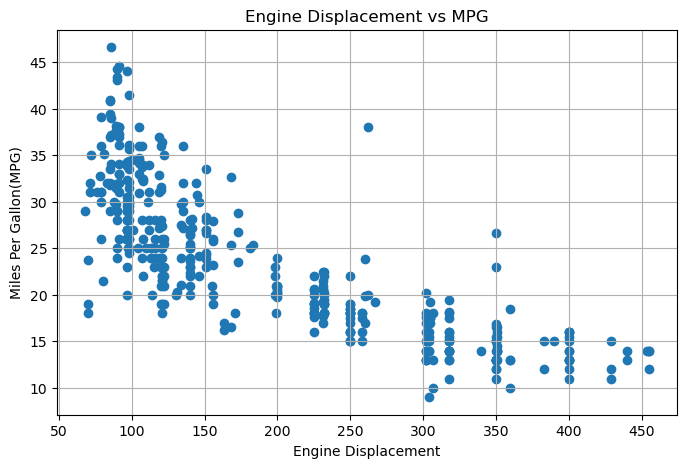

In [16]:
plt.figure(figsize=(8,5))

plt.scatter(x,y)

plt.xlabel("Engine Displacement")
plt.ylabel("Miles Per Gallon(MPG)")
plt.title("Engine Displacement vs MPG")

plt.grid(True)
plt.show()

In [18]:
#splitting the data
x_train,x_test,y_train,y_test=train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:",len(x_train))
print("Testig Samples:",len(x_test))

Training Samples: 318
Testig Samples: 80


In [23]:
#create Linear Regression Model
linear_model=LinearRegression()
#Train the Model
linear_model.fit(x_train,y_train)
#Predict on test data
y_pred_linear=linear_model.predict(x_test)

In [29]:
#Calculate MSE
mse_linear=mean_squared_error(y_test,y_pred_linear)
#Calculate R squared
r2_linear=r2_score(y_test,y_pred_linear)
print("Linear regression Results")
print("-------------------------")
print("MSE:",mse_linear)
print("R-square:",r2_linear)

Linear regression Results
-------------------------
MSE: 18.102543998358946
R-square: 0.6633114869465595


In [45]:
#Store Results
results=[]

polynomial_models={}

results.append({
    'Model':'Linear Regression',
    'Degree':1,
    'MSE':mse_linear,
    'R-squared':r2_linear
})
#try polynomial degree from 2 to 5
for degree in range(2,6):
    #create polynomial features
    poly=PolynomialFeatures(degree=degree)

    #transform training and test data
    x_train_poly=poly.fit_transform(x_train)
    x_test_poly=poly.fit_transform(x_test)

    poly_model=LinearRegression()

    poly_model.fit(x_train_poly,y_train)

    y_pred_poly=poly_model.predict(x_test_poly)
    #calculate evaluation metrics
    mse=mean_squared_error(y_test,y_pred_poly)
    r2=r2_score(y_test,y_pred_poly)
    #store Results
    results.append({
    'Model':'Polynomial Regression',
    'Degree':degree,
    'MSE':mse,
    'R-squared':r2
    })
    #store model and polynomial transformer
    polynomial_models[degree]={
    'poly':poly,
    'model':poly_model
    }

results_df=pd.DataFrame(results)

results_df

,Model,Degree,MSE,R-squared
0,Linear Regression,1,18.102544,0.663311
1,Polynomial Regression,2,15.107354,0.719019
2,Polynomial Regression,3,14.943632,0.722064
3,Polynomial Regression,4,14.961487,0.721732
4,Polynomial Regression,5,15.230896,0.716721


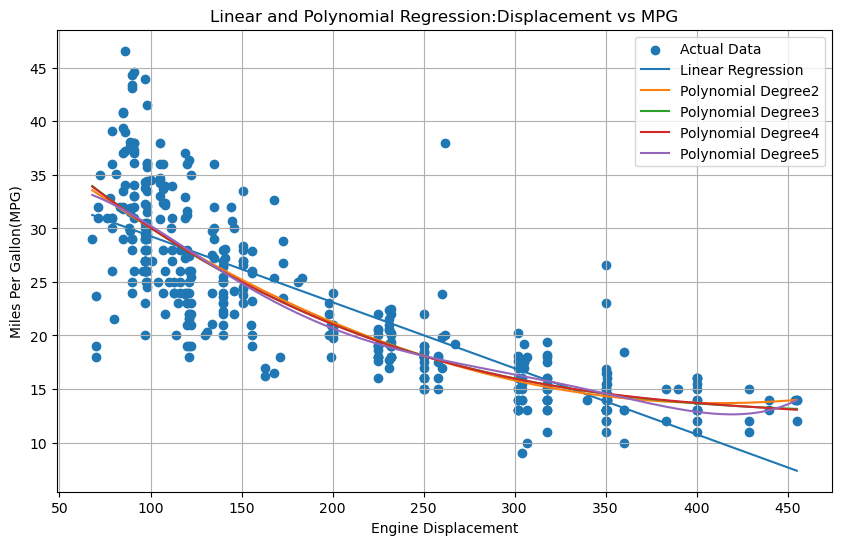

In [64]:
#create smooth x values for plotting
x_plot=pd.DataFrame({
    'displacement':np.linspace(
        x['displacement'].min(),
        x['displacement'].max(),
        300)
})
#create fig
plt.figure(figsize=(10,6))

#plot actual data
plt.scatter(
    x['displacement'],
    y,
    label='Actual Data'
)
#Plot Linear Regression

y_plot_linear=linear_model.predict(x_plot)

plt.plot(
    x_plot['displacement'],
    y_plot_linear,
    label='Linear Regression'
)
for degree in range(2,6):
    poly=polynomial_models[degree]['poly']
    poly_model=polynomial_models[degree]['model']

    x_plot_poly=poly.transform(x_plot)
    y_plot_poly=poly_model.predict(x_plot_poly)

    plt.plot(
        x_plot['displacement'],
        y_plot_poly,
        label=f'Polynomial Degree{degree}'
        
    )
plt.xlabel('Engine Displacement')
plt.ylabel('Miles Per Gallon(MPG)')

plt.title(
    'Linear and Polynomial Regression:Displacement vs MPG'
)
plt.legend()
plt.grid(True)
plt.show()

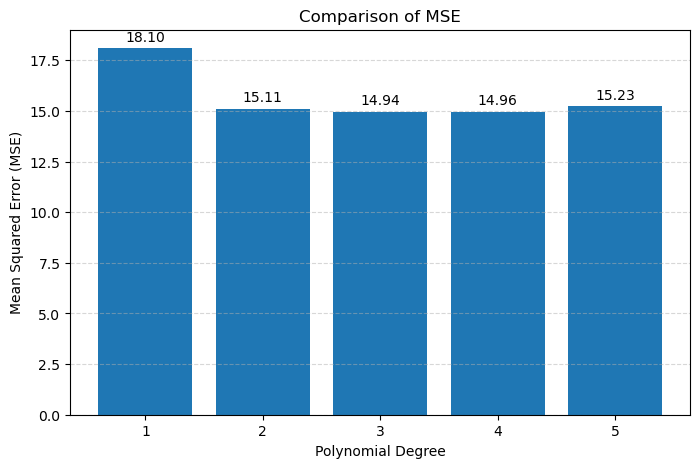

In [72]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

bars = plt.bar(
    results_df['Degree'].astype(str),
    results_df['MSE']
)

# Corrected: 'frmt' -> 'fmt'
plt.bar_label(bars, fmt='%.2f', padding=3)

plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Squared Error (MSE)")
plt.title("Comparison of MSE")
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

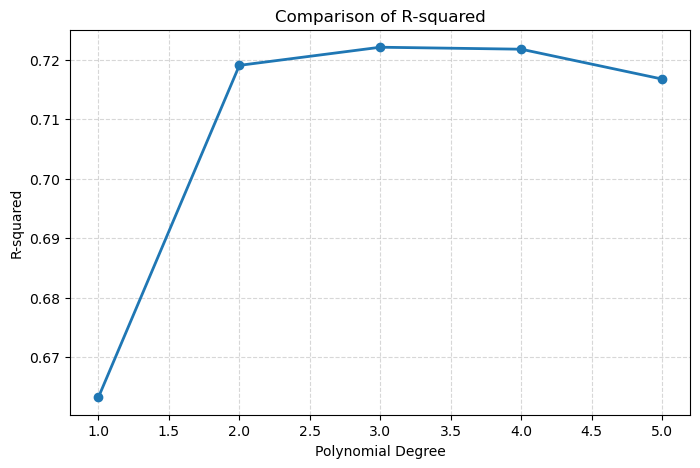

In [74]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    results_df['Degree'],      # Make sure the column is 'Degree'
    results_df['R-squared'],   # Make sure the column is 'R-squared'
    marker='o',
    linewidth=2,
    markersize=6
)

plt.xlabel("Polynomial Degree")
plt.ylabel("R-squared")
plt.title("Comparison of R-squared")
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()